# Data Preparation and Feature Engineering

## The Ames Housing Dataset

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

# Add project root to path
sys.path.insert(0, str(Path().resolve().parent))

from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

# ── Load data ──────────────────────────────────────────────────────────────
file_path = DATA_RAW / "housing.csv"

if file_path.exists():
    print("Loading data from local cache...")
    df = pd.read_csv(file_path)
else:
    print("Downloading dataset...")
    url = (
        "https://raw.githubusercontent.com/shoukewei/"
        "data-model/refs/heads/main/data/raw/housing.csv"
    )
    df = pd.read_csv(url)
    
    # Ensure directory exists
    file_path.parent.mkdir(parents=True, exist_ok=True)
    
    df.to_csv(file_path, index=False)
    print("Saved to local cache.")

# ── Basic info ─────────────────────────────────────────────────────────────
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")
print(f"\nFirst five columns:\n{df.iloc[:, :5].head()}")

Loading data from local cache...
Shape: (2930, 83)

Column dtypes:
str        43
int64      29
float64    11
Name: count, dtype: int64

First five columns:
   Unnamed: 0  Order        PID  MS SubClass MS Zoning
0           0      1  526301100           20        RL
1           1      2  526350040           20        RH
2           2      3  526351010           20        RL
3           3      4  526353030           20        RL
4           4      5  527105010           60        RL


### A First Look at the Data

In [45]:
# ── Structural overview ───────────────────────────────────
print(df.info(verbose=False, memory_usage="deep"))

# ── Missing values ────────────────────────────────────────
missing = (
    df.isnull()
      .sum()
      .rename("count")
      .to_frame()
      .assign(pct=lambda x: (x["count"] / len(df) * 100).round(1))
      .query("count > 0")
      .sort_values("count", ascending=False)
)
print(f"\nColumns with missing values ({len(missing)} total):\n{missing.head(20)}")

# ── Target variable ───────────────────────────────────────
print(f"\nSalePrice: min={df['SalePrice'].min():,}  "
      f"max={df['SalePrice'].max():,}  "
      f"mean={df['SalePrice'].mean():,.0f}")

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Columns: 83 entries, Unnamed: 0 to SalePrice
dtypes: float64(11), int64(29), str(43)
memory usage: 6.9 MB
None

Columns with missing values (27 total):
                count   pct
Pool QC          2917  99.6
Misc Feature     2824  96.4
Alley            2732  93.2
Fence            2358  80.5
Mas Vnr Type     1775  60.6
Fireplace Qu     1422  48.5
Lot Frontage      490  16.7
Garage Qual       159   5.4
Garage Cond       159   5.4
Garage Yr Blt     159   5.4
Garage Finish     159   5.4
Garage Type       157   5.4
Bsmt Exposure      83   2.8
BsmtFin Type 2     81   2.8
Bsmt Cond          80   2.7
Bsmt Qual          80   2.7
BsmtFin Type 1     80   2.7
Mas Vnr Area       23   0.8
Bsmt Full Bath      2   0.1
Bsmt Half Bath      2   0.1

SalePrice: min=12,789  max=755,000  mean=180,796


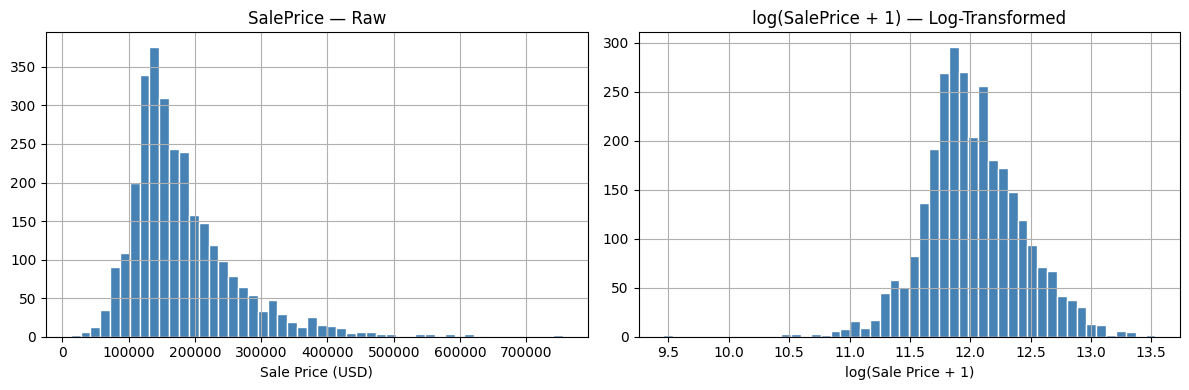

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Visualise the target distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["SalePrice"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("SalePrice — Raw")
axes[0].set_xlabel("Sale Price (USD)")

np.log1p(df["SalePrice"]).hist(bins=50, ax=axes[1],
                                color="steelblue", edgecolor="white")
axes[1].set_title("log(SalePrice + 1) — Log-Transformed")
axes[1].set_xlabel("log(Sale Price + 1)")

plt.tight_layout()
plt.savefig(FIGURES / "ch03_target_distribution.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Data Cleaning and Handling Missing Values

### Column Name Standardization

In [47]:
import re

def to_camel_case(col):
    # If already camelCase / PascalCase without separators → keep it
    if re.match(r'^[A-Za-z]+[A-Za-z0-9]*$', col) and not re.search(r'[\s/_\-]', col):
        return col[0].lower() + col[1:]  # only fix first letter if needed

    # Otherwise clean and convert
    col = re.sub(r"[/\-]", " ", col)
    col = re.sub(r"[^\w\s]", "", col)
    parts = col.strip().split()

    if not parts:
        return col

    return parts[0].lower() + ''.join(word.capitalize() for word in parts[1:])

# Rename columns in-place — no intermediate file save needed
name_map = {col: to_camel_case(col) for col in df.columns}   # original → camelCase
df = df.rename(columns=name_map)

print(f"\ndf renamed: {df.shape}, columns camelCase: {df.columns.tolist()[:5]}")
print("Column Name Mapping (first 15 shown):")
for orig, new in list(name_map.items())[:15]:
    print(f"{orig:<25} → {new}")


df renamed: (2930, 83), columns camelCase: ['unnamed0', 'order', 'pID', 'msSubclass', 'msZoning']
Column Name Mapping (first 15 shown):
Unnamed: 0                → unnamed0
Order                     → order
PID                       → pID
MS SubClass               → msSubclass
MS Zoning                 → msZoning
Lot Frontage              → lotFrontage
Lot Area                  → lotArea
Street                    → street
Alley                     → alley
Lot Shape                 → lotShape
Land Contour              → landContour
Utilities                 → utilities
Lot Config                → lotConfig
Land Slope                → landSlope
Neighborhood              → neighborhood


### Auditing Missing Data by Type

In [48]:
# ── Classify missing columns (using actual column names from the data) ────────

# Group 1: Structural — NaN means "None / absent" (categorical)
structural_none = [
    "poolQc", "miscFeature", "alley", "fence", "fireplaceQu",
    "garageType", "garageFinish", "garageQual", "garageCond",
    "bsmtQual", "bsmtCond", "bsmtExposure", "bsmtfinType1", "bsmtfinType2",
    "masVnrType",
]

# Group 2: Structural — NaN means 0 (numeric)
structural_zero = [
    "garageYrBlt", "garageArea", "garageCars",
    "bsmtfinSf1", "bsmtfinSf2", "bsmtUnfSf", "totalBsmtSf",
    "bsmtFullBath", "bsmtHalfBath", "masVnrArea",
]

# Group 3: Informative / requires special treatment
informative = ["lotFrontage"]

# Group 4: Small random missing — mode imputation
random_small = ["electrical"]   # only 1 missing value

print("Missing value groups defined with exact camelCase column names.")

Missing value groups defined with exact camelCase column names.


### Handling Structural Missing Values

In [49]:
def fill_structural(df: pd.DataFrame) -> pd.DataFrame:
    """Fill structural NaN values that encode absence of a feature."""
    df = df.copy()

    for col in structural_none:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    for col in structural_zero:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    return df

df = fill_structural(df)

# Verify — only check columns that actually exist in df
cols_to_check = [c for c in structural_none + structural_zero if c in df.columns]
remaining_structural = df[cols_to_check].isnull().sum()
print("Remaining missing after structural fill:")
print(remaining_structural[remaining_structural > 0])
# → Empty Series — all structural NaN resolved

Remaining missing after structural fill:
Series([], dtype: int64)


### Imputing LotFrontage by Neighbourhood

In [50]:
def impute_lot_frontage(df: pd.DataFrame) -> pd.DataFrame:
    """Impute lotFrontage using the median within each neighborhood."""
    df = df.copy()
    df["lotFrontage"] = df.groupby("neighborhood")["lotFrontage"].transform(
        lambda x: x.fillna(x.median())
    )
    # Fall back to global median
    global_median = df["lotFrontage"].median()
    df["lotFrontage"] = df["lotFrontage"].fillna(global_median)
    return df

df = impute_lot_frontage(df)
print(f"LotFrontage missing after imputation: {df['lotFrontage'].isnull().sum()}")

LotFrontage missing after imputation: 0


### Handling Small Random Missing Values

In [51]:
# Electrical: 1 missing — fill with mode (most common value)
df["electrical"] = df["electrical"].fillna(df["electrical"].mode()[0])

# Final check
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values remaining: {total_missing}")


Total missing values remaining: 0


### Removing Low-Information Columns

In [52]:
def drop_low_info_columns(
    df: pd.DataFrame,
    max_categories: int = 50,
) -> pd.DataFrame:
    """
    Drop columns that are unlikely to carry predictive signal:
    - Near-constant columns (one value covers >99% of rows)
    - Identifier columns
    """
    df = df.copy()
    to_drop = []

    # Identifier
    if "id" in df.columns:
        to_drop.append("id")

    # Near-constant
    for col in df.select_dtypes(include="number").columns:
        if col == "salePrice":
            continue
        top_freq = df[col].value_counts(normalize=True).iloc[0]
        if top_freq >= 0.99:
            to_drop.append(col)

    print(f"Dropping {len(to_drop)} low-information columns: {to_drop}")
    return df.drop(columns=to_drop)

df = drop_low_info_columns(df)

Dropping 1 low-information columns: ['poolArea']


### Outlier Detection and Treatment

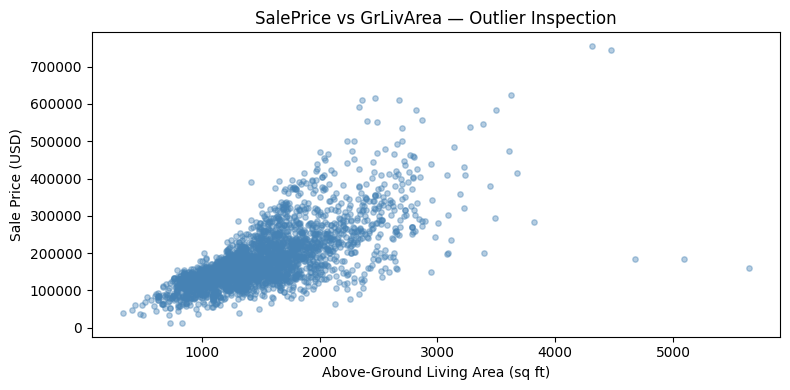

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df["grLivArea"], df["salePrice"],
           alpha=0.4, s=15, color="steelblue")
ax.set_xlabel("Above-Ground Living Area (sq ft)")
ax.set_ylabel("Sale Price (USD)")
ax.set_title("SalePrice vs GrLivArea — Outlier Inspection")
plt.tight_layout()
plt.savefig(FIGURES / "ch03_outlier_inspection.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
# Two properties with GrLivArea > 4,000 sq ft sold for < $200,000
# These are partial sales or data errors — remove them
outlier_mask = (df["grLivArea"] > 4000) & (df["salePrice"] < 200_000)
print(f"Outliers identified: {outlier_mask.sum()}")
df = df[~outlier_mask].reset_index(drop=True)
print(f"Dataset shape after outlier removal: {df.shape}")

Outliers identified: 3
Dataset shape after outlier removal: (2927, 82)


## Feature Transformation and Scaling

### Log-Transforming Skewed Numeric Features

In [55]:
from scipy.stats import skew

# Identify numeric features excluding the target
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "salePrice"]

skewness = (
    df[numeric_cols]
    .apply(skew)
    .rename("skewness")
    .to_frame()
    .assign(abs_skew=lambda x: x["skewness"].abs())
    .sort_values("abs_skew", ascending=False)
)
print("Top 10 most skewed numeric features:")
print(skewness.head(10).round(3))

Top 10 most skewed numeric features:
               skewness  abs_skew
miscVal          22.221    22.221
lotArea          13.179    13.179
lowQualFinSf     12.106    12.106
3ssnPorch        11.392    11.392
kitchenAbvgr      4.309     4.309
bsmtfinSf2        4.136     4.136
enclosedPorch     4.010     4.010
screenPorch       3.953     3.953
bsmtHalfBath      3.952     3.952
garageYrBlt      -3.913     3.913


In [56]:
import numpy as np

SKEW_THRESHOLD = 0.75

def apply_log1p_transform(
    df: pd.DataFrame,
    threshold: float = SKEW_THRESHOLD,
    exclude: list[str] | None = None,
) -> tuple[pd.DataFrame, list[str]]:
    """
    Apply log1p to all numeric columns with |skewness| > threshold.
    Returns the transformed DataFrame and the list of columns transformed.
    """
    df = df.copy()
    exclude = exclude or []
    numeric = df.select_dtypes(include="number").columns
    candidates = [c for c in numeric if c not in exclude and c != "salePrice"]

    transformed = []
    for col in candidates:
        if abs(skew(df[col].dropna())) > threshold:
            df[col] = np.log1p(df[col])
            transformed.append(col)

    print(f"log1p applied to {len(transformed)} columns.")
    return df, transformed

df, log_transformed_cols = apply_log1p_transform(df)

# Also transform the target
df["salePrice"] = np.log1p(df["salePrice"])
print(f"\nlog(SalePrice) skewness: {skew(df['salePrice']):.3f}")

log1p applied to 20 columns.

log(SalePrice) skewness: -0.014


### Feature Scaling

In [57]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

# Demonstrate StandardScaler on three key numeric features
demo_cols = ["grLivArea", "lotArea", "totalBsmtSf"]
scaler = StandardScaler()

scaled_array = scaler.fit_transform(df[demo_cols])
df_scaled_demo = pd.DataFrame(scaled_array, columns=demo_cols)

print("Before scaling (first 3 rows):")
print(df[demo_cols].head(3).round(2))
print("\nAfter StandardScaler (first 3 rows):")
print(df_scaled_demo.head(3).round(4))
print("\nVerify: mean≈0, std≈1:")
print(df_scaled_demo.describe().loc[["mean","std"]].round(4))

Before scaling (first 3 rows):
   grLivArea  lotArea  totalBsmtSf
0       7.41    10.37       1080.0
1       6.80     9.36        882.0
2       7.19     9.57       1329.0

After StandardScaler (first 3 rows):
   grLivArea  lotArea  totalBsmtSf
0     0.4759   2.5091       0.0770
1    -1.4304   0.5312      -0.3913
2    -0.2069   0.9345       0.6660

Verify: mean≈0, std≈1:
      grLivArea  lotArea  totalBsmtSf
mean    -0.0000   0.0000      -0.0000
std      1.0002   1.0002       1.0002


### Visualising the Effect of Transformations

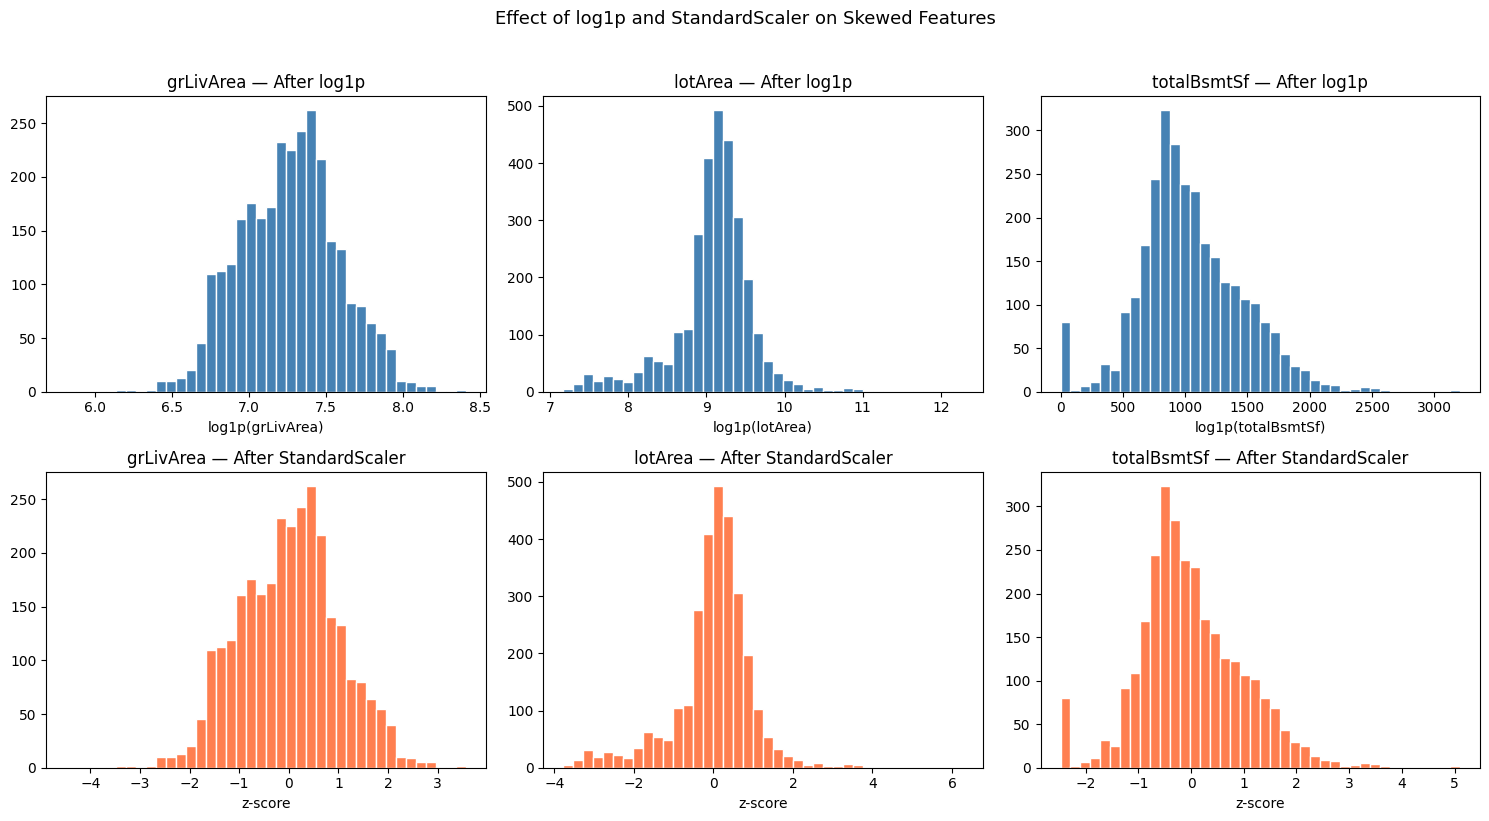

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(["grLivArea", "lotArea", "totalBsmtSf"]):
    # Raw distribution
    axes[0, i].hist(df[col], bins=40, color="steelblue", edgecolor="white")
    axes[0, i].set_title(f"{col} — After log1p")
    axes[0, i].set_xlabel(f"log1p({col})")

    # Z-score scaled
    scaled = (df[col] - df[col].mean()) / df[col].std()
    axes[1, i].hist(scaled, bins=40, color="coral", edgecolor="white")
    axes[1, i].set_title(f"{col} — After StandardScaler")
    axes[1, i].set_xlabel("z-score")

plt.suptitle("Effect of log1p and StandardScaler on Skewed Features",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch03_transformations.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Encoding Categorical Variables

### Ordinal Encoding

In [59]:
from sklearn.preprocessing import OrdinalEncoder

QUALITY_MAP = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

ordinal_quality_cols = [
    "exterQual", "exterCond", "bsmtQual", "bsmtCond",
    "heatingQc", "kitchenQual", "firePlaceQu",
    "garageQual", "garageCond", "poolQc",
]

def encode_quality_columns(
    df: pd.DataFrame,
    cols: list[str],
    mapping: dict[str, int],
) -> pd.DataFrame:
    """Map ordered quality strings to integers."""
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = df[col].map(mapping)
    return df

df = encode_quality_columns(df, ordinal_quality_cols, QUALITY_MAP)
print("Sample quality encodings:")
print(df[["exterQual", "bsmtQual", "kitchenQual"]].value_counts().head(8))

Sample quality encodings:
exterQual  bsmtQual  kitchenQual
3          3         3              932
4          4         4              689
3          4         3              330
           3         4              194
           4         4              116
4          5         4               92
5          5         5               81
3          0         3               62
Name: count, dtype: int64


In [60]:
OTHER_ORDINAL = {
    "lotShape":     {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "landSlope":    {"Sev": 0, "Mod": 1, "Gtl": 2},
    "bsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "bsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3,
                     "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "garageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "functional":   {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3,
                     "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},
    "pavedDrive":   {"N": 0, "P": 1, "Y": 2},
    "fence":        {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "gdprv": 4},
}

for col, mapping in OTHER_ORDINAL.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

print("Ordinal encoding complete.")

Ordinal encoding complete.


### One-Hot Encoding (Nominal Variables)

In [61]:
nominal_cols = [
    "msZoning", "street", "alley", "landContour", "lotConfig",
    "neighborhood", "condition1", "condition2", "bldgType", 
    "houseStyle", "roofStyle", "roofMatl", "exterior1st", 
    "exterior2nd", "masVnrType", "foundation", "heating", 
    "centralAir", "electrical", "garageType", "miscFeature", 
    "saleType", "saleCondition"
]

# Filter to columns actually present after earlier steps
nominal_present = [c for c in nominal_cols if c in df.columns]

df_encoded = pd.get_dummies(
    df,
    columns=nominal_present,
    drop_first=True,          # drop one level per variable to avoid multicollinearity
    dtype=float,
)

print(f"Shape before one-hot encoding: {df.shape}")
print(f"Shape after  one-hot encoding: {df_encoded.shape}")

Shape before one-hot encoding: (2927, 82)
Shape after  one-hot encoding: (2927, 213)


### Target Encoding (High-Cardinality Categoricals)

In [62]:
def target_encode(
    train: pd.DataFrame,
    val: pd.DataFrame,
    col: str,
    target: str,
    smoothing: float = 10.0,
) -> tuple[pd.Series, pd.Series]:
    """
    Smoothed target encoding.
    
    The smoothed estimate blends the category mean toward the global mean,
    weighted by the number of observations in that category.
    This reduces overfitting for low-frequency categories.
    """
    global_mean = train[target].mean()
    stats = train.groupby(col)[target].agg(["mean", "count"])
    
    # Smoothed estimate: weighted blend of category mean and global mean
    smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / \
             (stats["count"] + smoothing)
    
    train_encoded = train[col].map(smooth).fillna(global_mean)
    val_encoded   = val[col].map(smooth).fillna(global_mean)
    
    return train_encoded, val_encoded

## Feature Construction and Selection

### Constructing New Features from Domain Knowledge

In [63]:
import pandas as pd

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construct domain-informed features for the Ames Housing dataset.
    All operations use only information available at the time of sale.
    """
    df = df.copy()

    # ── Age and renovation ─────────────────────────────────────────────────
    # Input Corrected: yrSold, yearBuilt, yearRemodAdd
    df["houseAge"]        = df["yrSold"] - df["yearBuilt"]
    df["yearsSinceRemod"] = df["yrSold"] - df["yearRemodAdd"]
    df["isRemodeled"]     = (df["yearRemodAdd"] != df["yearBuilt"]).astype(int)

    # ── Total area ─────────────────────────────────────────────────────────
    # Input Corrected: totalBsmtSf, grLivArea
    df["totalSf"]         = df["totalBsmtSf"] + df["grLivArea"]
    
    # Input Corrected: fullBath, halfBath, bsmtFullBath, bsmtHalfBath
    df["totalBathrooms"]  = (df["fullBath"]
                             + 0.5 * df["halfBath"]
                             + df["bsmtFullBath"]
                             + 0.5 * df["bsmtHalfBath"])

    # ── Porch and outdoor space ────────────────────────────────────────────
    # Input Corrected: openPorchSf, enclosedPorch, 3ssnPorch, screenPorch
    df["totalPorchSf"]    = (df["openPorchSf"] + df["enclosedPorch"]
                             + df["3ssnPorch"] + df["screenPorch"])

    # ── Quality × size interaction ─────────────────────────────────────────
    # Input Corrected: overallQual, grLivArea
    df["qualityAreaInt"]  = df["overallQual"] * df["grLivArea"]

    # ── Seasonal sale indicator ────────────────────────────────────────────
    # Input Corrected: moSold
    df["isPeakSeason"]    = df["moSold"].isin([4, 5, 6, 7]).astype(int)

    # ── Has pool / fireplace / garage ─────────────────────────────────────
    # Input Corrected: poolArea, fireplaces, garageArea
    # Using .get() with a default series to handle missing columns safely
    df["hasPool"]         = (df.get("poolArea", pd.Series(0, index=df.index)) > 0).astype(int)
    df["hasFireplace"]    = (df["fireplaces"] > 0).astype(int)
    df["hasGarage"]       = (df["garageArea"] > 0).astype(int)

    return df

# Apply the feature engineering
df = build_features(df)

print("New features added:")
new_features = [
    "houseAge", "yearsSinceRemod", "isRemodeled", "totalSf",
    "totalBathrooms", "totalPorchSf", "qualityAreaInt",
    "isPeakSeason", "hasPool", "hasFireplace", "hasGarage"
]

print(df[new_features].describe().round(2))

New features added:
       houseAge  yearsSinceRemod  isRemodeled  totalSf  totalBathrooms  \
count   2927.00          2927.00      2927.00  2927.00         2927.00   
mean      36.47            23.55         0.46  1054.69            2.21   
std       30.28            20.85         0.50   423.00            0.81   
min        0.00            -1.00         0.00     5.81            1.00   
25%        7.00             4.00         0.00   799.50            1.50   
50%       34.00            15.00         0.00   996.90            2.00   
75%       54.00            43.00         1.00  1307.11            2.50   
max      136.00            60.00         1.00  3213.40            7.00   

       totalPorchSf  qualityAreaInt  isPeakSeason  hasPool  hasFireplace  \
count       2927.00         2927.00       2927.00   2927.0       2927.00   
mean           3.61           44.48          0.56      0.0          0.51   
std            2.89           11.52          0.50      0.0          0.50   
min      

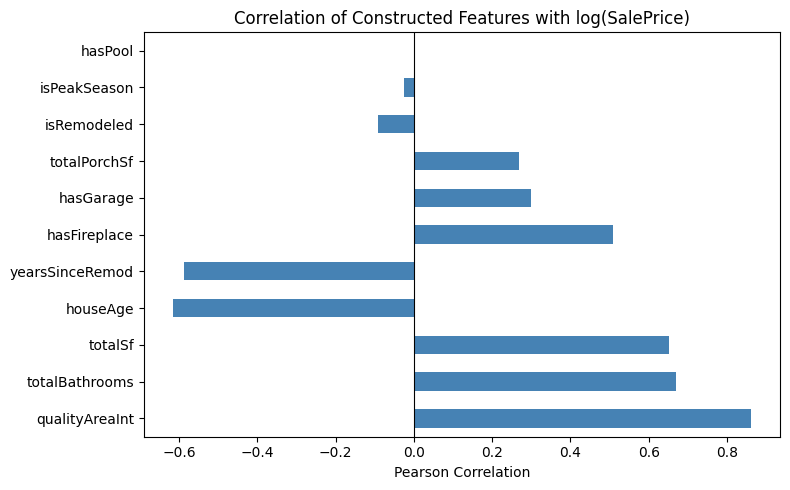

In [64]:
correlations = df[new_features + ["salePrice"]].corr()["salePrice"] \
                  .drop("salePrice") \
                  .sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of Constructed Features with log(SalePrice)")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig(FIGURES / "ch03_constructed_feature_correlations.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Polynomial and Interaction Features

In [65]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Demonstrate on OverallQual and GrLivArea
X_demo = df[["overallQual", "grLivArea"]].values
poly = PolynomialFeatures(degree=2, interaction_only=False,
                           include_bias=False)
X_poly = poly.fit_transform(X_demo)

print("Original features:  ", X_demo.shape)
print("After degree-2 poly:", X_poly.shape)
print("Feature names:", poly.get_feature_names_out(
    ["overallQual", "grLivArea"]
))

Original features:   (2927, 2)
After degree-2 poly: (2927, 5)
Feature names: ['overallQual' 'grLivArea' 'overallQual^2' 'overallQual grLivArea'
 'grLivArea^2']


### Feature Selection

#### Filter Methods: Correlation and Mutual Information

In [66]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split

# Prepare a clean numeric matrix
X = df_encoded.drop(columns=["salePrice"])
y = df_encoded["salePrice"]

# Ensure all-numeric, no NaN
X = X.select_dtypes(include="number").fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# Mutual information — captures non-linear associations
mi_scores = mutual_info_regression(
    X_train, y_train, random_state=RANDOM_SEED
)
mi_series = pd.Series(mi_scores, index=X_train.columns) \
              .sort_values(ascending=False)

print("Top 15 features by mutual information:")
print(mi_series.head(15).round(4))

Top 15 features by mutual information:
overallQual     0.6047
grLivArea       0.4919
yearBuilt       0.3985
garageArea      0.3886
totalBsmtSf     0.3742
garageCars      0.3737
bsmtQual        0.3653
1stFlrSf        0.3393
kitchenQual     0.3218
exterQual       0.3132
yearRemodAdd    0.2989
msSubclass      0.2970
garageYrBlt     0.2879
fullBath        0.2619
order           0.2515
dtype: float64


#### Wrapper Methods: Recursive Feature Elimination (RFE)

In [67]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge

# Use stronger regularization to avoid ill-conditioned matrix warnings
ridge_estimator = Ridge(alpha=1.0)

# RFE: select top 30 features
rfe = RFE(
    estimator=ridge_estimator,
    n_features_to_select=30,
    step=10          # remove 10 features at each iteration
)

rfe.fit(X_train, y_train)

# Get selected feature names
rfe_selected = X_train.columns[rfe.support_].tolist()

print(f"RFE selected {len(rfe_selected)} features out of {X_train.shape[1]} total features.\n")
print("Top 20 selected features:")
for i, feat in enumerate(rfe_selected[:20], 1):
    print(f"{i:2d}. {feat}")

F:\project-workspace\quarto-book\data-model-book\data-model\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.687609654125626e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


RFE selected 30 features out of 208 total features.

Top 20 selected features:
 1. lotArea
 2. overallQual
 3. 1stFlrSf
 4. grLivArea
 5. bsmtFullBath
 6. bsmtHalfBath
 7. kitchenAbvgr
 8. msZoning_FV
 9. msZoning_I (all)
10. msZoning_RH
11. msZoning_RL
12. msZoning_RM
13. neighborhood_Crawfor
14. neighborhood_GrnHill
15. neighborhood_NoRidge
16. neighborhood_NridgHt
17. neighborhood_StoneBr
18. exterior1st_PreCast
19. exterior2nd_PreCast
20. masVnrType_CBlock


#### Embedded Methods: Lasso Regularization


Lasso (α=0.0018) selected 119 features out of 208.


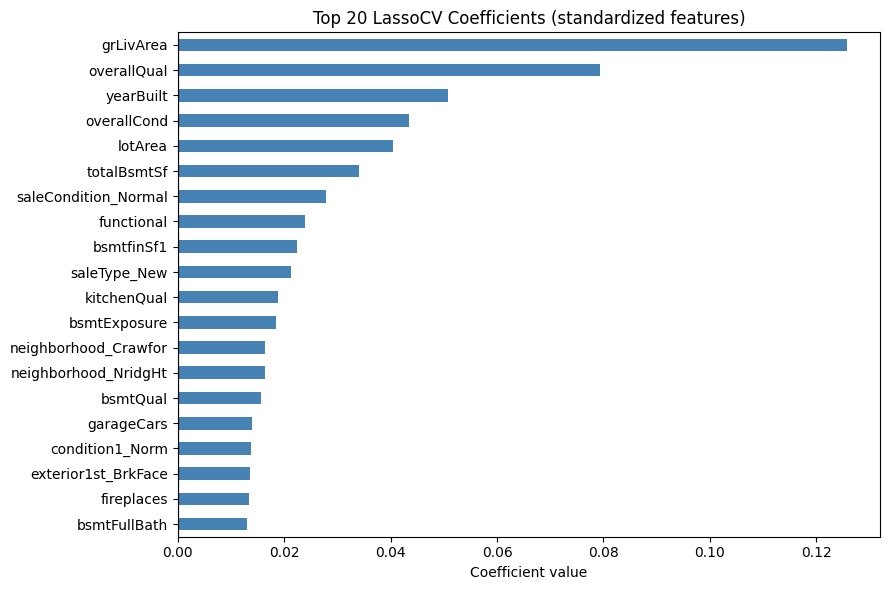

In [68]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# Scale before Lasso — Lasso is sensitive to scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# LassoCV finds the optimal alpha via cross-validation
lasso_cv = LassoCV(cv=5, random_state=RANDOM_SEED, max_iter=5000)
lasso_cv.fit(X_train_scaled, y_train)

nonzero_mask = lasso_cv.coef_ != 0
lasso_selected = X_train.columns[nonzero_mask].tolist()
print(f"\nLasso (α={lasso_cv.alpha_:.4f}) selected "
      f"{len(lasso_selected)} features out of {X_train.shape[1]}.")

# Visualise coefficient magnitudes for selected features — see @fig-lasso-coefficients
coefs = pd.Series(lasso_cv.coef_[nonzero_mask],
                  index=lasso_selected).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
coefs.head(20).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 LassoCV Coefficients (standardized features)")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.savefig(FIGURES / "ch03_lasso_coefficients.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Save the Final Processed Data

In [69]:
# Make sure engineered features are applied to the encoded dataframe
if 'houseAge' not in df_encoded.columns:
    df_encoded = build_features(df_encoded)

# 1. Rich processed version (df_encoded):
#    log1p numerics + ordinal encoding + one-hot encoding + engineered features
#    Every column is numeric. Use for regularized regression and full modeling.
df_processed = df_encoded.copy()

df_processed.to_csv(DATA_PROCESSED / "housing_processed.csv", index=False)

print(f"✅ Rich processed dataset saved:")
print(f"   → {DATA_PROCESSED / 'housing_processed.csv'}")
print(f"   Shape: {df_processed.shape[0]:,} rows × {df_processed.shape[1]} columns")
print("   (log1p numerics, ordinal + one-hot encoding, engineered features — fully numeric)")

# 2. Readable version (df):
#    log1p numerics + ordinal encoding + engineered features
#    Nominal categoricals remain as strings. Use for interpretable OLS models.
df_readable = df.copy()

df_readable.to_csv(DATA_PROCESSED / "housing_ols_ready.csv", index=False)

print(f"✅ Readable dataset saved:")
print(f"   → {DATA_PROCESSED / 'housing_ols_ready.csv'}")
print(f"   Shape: {df_readable.shape[0]:,} rows × {df_readable.shape[1]} columns")
print("   (log1p numerics, ordinal encoding, engineered features — nominals still as strings)")

✅ Rich processed dataset saved:
   → F:\project-workspace\quarto-book\data-model-book\data-model\data\processed\housing_processed.csv
   Shape: 2,927 rows × 224 columns
   (log1p numerics, ordinal + one-hot encoding, engineered features — fully numeric)
✅ Readable dataset saved:
   → F:\project-workspace\quarto-book\data-model-book\data-model\data\processed\housing_ols_ready.csv
   Shape: 2,927 rows × 93 columns
   (log1p numerics, ordinal encoding, engineered features — nominals still as strings)


## Assembling the Full Pipeline

In [70]:
## Assembling the Full Pipeline

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ── Load the rich processed dataset ───────────────────────────────────────
df = pd.read_csv(DATA_PROCESSED / "housing_processed.csv")

print(f"Loaded rich processed dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Drop identifier columns
df = df.drop(columns=['unnamed0', 'order', 'pID'], errors='ignore')

X = df.drop(columns=['salePrice'])
y = df['salePrice']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# ── Identify numeric features ─────────────────────────────────────────────
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Remaining categorical features (dropped): {len(categorical_features)}")

# ── Preprocessor with imputation + scaling ────────────────────────────────
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),   # ← This fixes the NaN error
        ("scaler", StandardScaler())
    ]), numeric_features),
    
    ("drop_cat", "drop", categorical_features)
], remainder="passthrough")

# Full pipeline
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0))
])

# Fit and evaluate
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n✅ Full Pipeline Performance (Ridge on rich feature set)")
print(f"Test RMSE (log scale): {rmse:.4f}")
print(f"Test R²:               {r2:.4f}")
print(f"Approx. median % error: ~{np.expm1(rmse) * 100 - 100:.1f}%")

Loaded rich processed dataset: 2,927 rows × 224 columns
Numeric features: 216
Remaining categorical features (dropped): 4

✅ Full Pipeline Performance (Ridge on rich feature set)
Test RMSE (log scale): 0.0964
Test R²:               0.9483
Approx. median % error: ~-89.9%


### Save the Fitted Pipeline

In [71]:
import joblib

joblib.dump(full_pipeline, DATA_PROCESSED / "housing_preprocessing_pipeline.pkl")
print(f"\nPipeline saved → {DATA_PROCESSED / 'housing_preprocessing_pipeline.pkl'}")


Pipeline saved → F:\project-workspace\quarto-book\data-model-book\data-model\data\processed\housing_preprocessing_pipeline.pkl
